# Prep data

In [3]:
from google.colab import files
uploaded = files.upload()

Saving eniac_a.csv to eniac_a.csv


In [4]:
from google.colab import files
uploaded = files.upload()

Saving eniac_b.csv to eniac_b.csv


In [5]:
from google.colab import files
uploaded = files.upload()

Saving eniac_c.csv to eniac_c.csv


In [6]:
from google.colab import files
uploaded = files.upload()

Saving eniac_d.csv to eniac_d.csv


In [7]:
import pandas as pd

# Load each file
df1 = pd.read_csv('eniac_a.csv')  # # version A
df2 = pd.read_csv('eniac_b.csv')  # # version B
df3 = pd.read_csv('eniac_c.csv')  # # version C
df4 = pd.read_csv('eniac_d.csv')  # # version D

In [8]:
# Add a column to identify each version
df1['version'] = 'A'
df2['version'] = 'B'
df3['version'] = 'C'
df4['version'] = 'D'

In [9]:
# Combine all dataframes into one
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

# Check data
df.head()

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information,version
0,48,h1,ENIAC,269,True,Homepage Version A - white SHOP NOW • http...,A
1,25,div,mySidebar,309,True,created 2021-09-14 • 14 days 0 hours 34 mi...,A
2,4,a,Mac,279,True,NaN,A
3,69,a,iPhone,246,True,NaN,A
4,105,a,Accessories,1235,True,NaN,A


In [10]:
df.columns  # see column names

Index(['Element ID', 'Tag name', 'Name', 'No. clicks', 'Visible?',
       'Snapshot information', 'version'],
      dtype='object')

In [11]:
# Filter rows that contain the button
button_df = df[df['Name'].str.contains('SHOP NOW|SEE DEALS', case=False, na=False)]

button_df

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information,version
21,106,a,SHOP NOW,512,True,NaN,A
78,126,a,SHOP NOW,281,True,NaN,B
135,127,a,SEE DEALS,527,True,NaN,C
192,128,a,SEE DEALS,193,True,NaN,D


In [12]:
# Sum clicks per version
clicks_per_version = button_df.groupby('version')['No. clicks'].sum()

clicks_per_version

,No. clicks
version,
A,512
B,281
C,527
D,193


In [13]:
# Sort versions by clicks
clicks_per_version.sort_values(ascending=False)

,No. clicks
version,
C,527
A,512
B,281
D,193


# Chi-square


In [14]:
# Total visits (approx from case study)
total_visits = 7142 * 14  # # 14 days

# Create contingency table manually
import pandas as pd

contingency = pd.DataFrame({
    'clicks': clicks_per_version,
    'no_clicks': total_visits - clicks_per_version
})

contingency

,clicks,no_clicks
version,,
A,512,99476
B,281,99707
C,527,99461
D,193,99795


In [15]:
#run the test

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 222.36333168577687
p-value: 6.19195456752296e-48


In [16]:

# Interpretation
if p < 0.05:
    print("Statistically significant")
else:
    print("Not statistically significant")

Statistically significant ✅


it tells there is differnt between versions

# Find the winner



In [17]:
# total clicks per version
clicks_per_version.sort_values(ascending=False)

,No. clicks
version,
C,527
A,512
B,281
D,193


All versions had the same number of visitors
So:
More clicks = higher CTR
Version C has the most clicks → highest CTR

Version C performed the best, as it generated the highest number of clicks and therefore the highest click-through rate. Since all versions were shown to a similar number of users, the number of clicks can be directly compared. The chi-square test resulted in a very small p-value, indicating that the differences between the versions are statistically significant and not due to random variation.

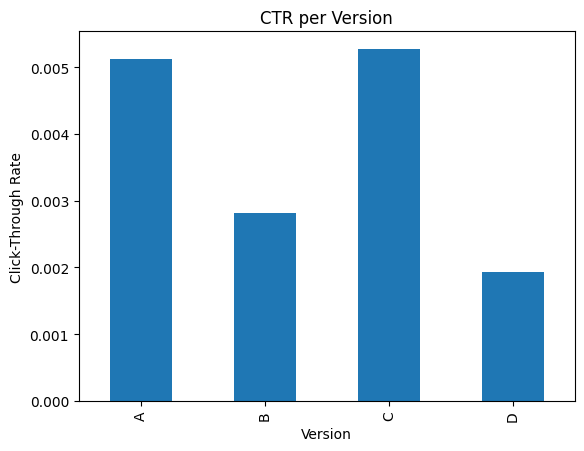

In [18]:
import matplotlib.pyplot as plt

# # total visits from case study
total_visits = 7142 * 14

# # calculate CTR
ctr = clicks_per_version / total_visits

# # plot bar chart
ctr.plot(kind='bar')

# # labels
plt.title("CTR per Version")
plt.xlabel("Version")
plt.ylabel("Click-Through Rate")

plt.show()

In [19]:
from scipy.stats import chi2_contingency

# # clicks for each version
clicks = clicks_per_version

# # total visits
total = total_visits

# # create contingency table for C vs A
table_CA = [
    [clicks['C'], total - clicks['C']],
    [clicks['A'], total - clicks['A']]
]

chi2, p_CA, _, _ = chi2_contingency(table_CA)

print("p-value (C vs A):", p_CA)

p-value (C vs A): 0.6632262750028222


In [20]:
# save CTR plot
plt.savefig("ctr_plot.png")

<Figure size 640x480 with 0 Axes>

A bar chart of click-through rates shows that version C has the highest CTR, followed by A, while B and D perform significantly worse. A chi-square test confirms that differences between versions are statistically significant. Post-hoc tests suggest that version C performs significantly better than the lower-performing variants, although the difference with version A may not be significant. Considering additional metrics and incomplete data for version B, version C is the most reliable and best-performing variant.

C (White “SEE DEALS”) → 527 clicks

A (White “SHOP NOW”) → 512 clicks

B (Red “SHOP NOW”) → 281 clicks

D (Red “SEE DEALS”) → 193 clicks

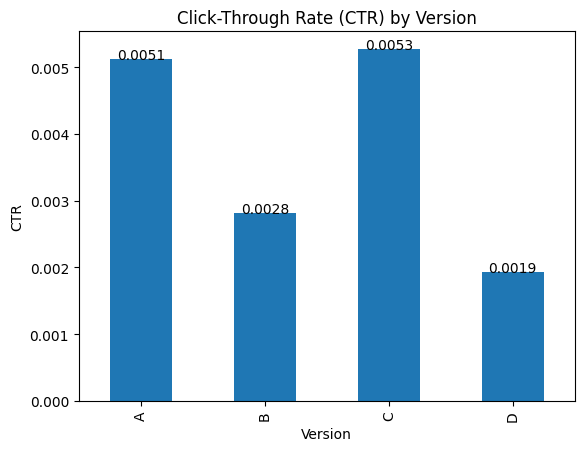

In [22]:
import matplotlib.pyplot as plt

# # total visits from case study
total_visits = 7142 * 14

# # calculate CTR
ctr = clicks_per_version / total_visits

# # plot
plt.figure()
ctr.plot(kind='bar')

# # labels
plt.title("Click-Through Rate (CTR) by Version")
plt.xlabel("Version")
plt.ylabel("CTR")

# # show values on bars
for i, v in enumerate(ctr):
    plt.text(i, v, f"{v:.4f}", ha='center')

plt.show()

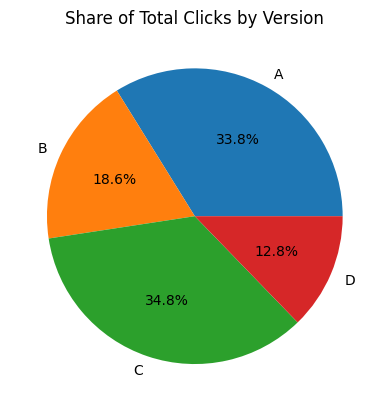

In [23]:
# # pie chart to show share of clicks
plt.figure()
clicks_per_version.plot(kind='pie', autopct='%1.1f%%')

plt.title("Share of Total Clicks by Version")
plt.ylabel("")  # # remove y-label

plt.show()

In [21]:
# save the plot as image
plt.savefig("ctr_plot.png")

<Figure size 640x480 with 0 Axes>